/tmp/ipykernel_460/3554215576.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2026-01-01', end='2026-04-30', freq='H')


✅ Data Preprocessing Complete.
Total Logged Days: 120


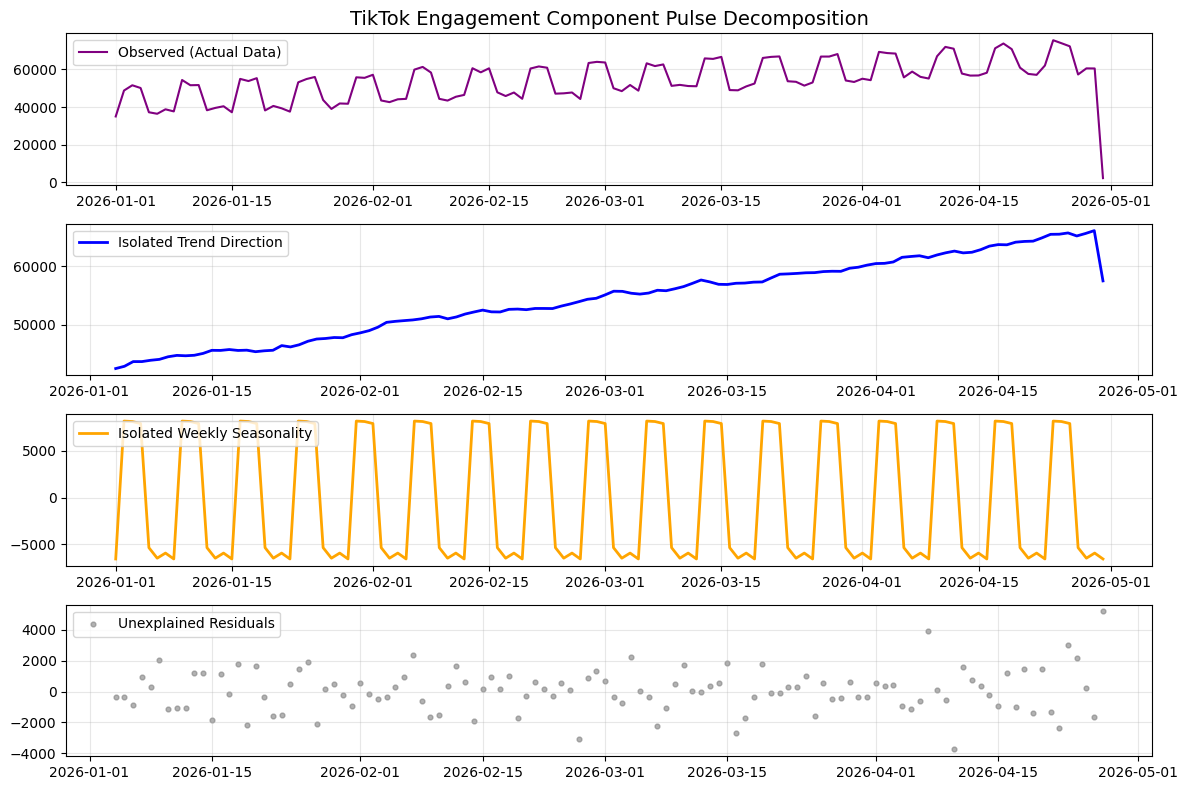


--- 🔬 AUGMENTED DICKEY-FULLER (ADF) STATIONARITY MATRIX ---
ADF Test Statistic:      -1.6281
p-value:                 4.6847e-01
Critical Mathematical Values Table:
   1%: -3.4936
   5%: -2.8892
   10%: -2.5815

Statistical Decision: Fail to Reject H0. Trend-Differencing (df_daily.diff()) is strictly REQUIRED.


/tmp/ipykernel_460/3554215576.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_profile.index, y=weekly_profile.values, palette='plasma', edgecolor='black')


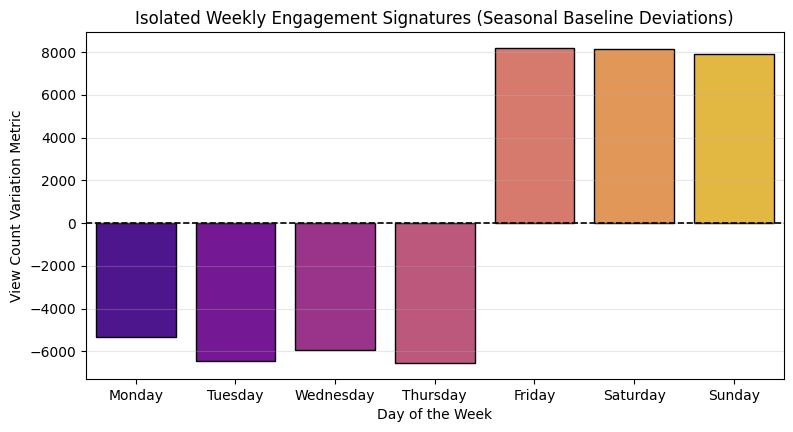


--- 📈 EXACT BASELINE DEVIATIONS BY WEEKDAY ---
Monday    : Baseline Deviation: -5339.26 views
Tuesday   : Baseline Deviation: -6463.86 views
Wednesday : Baseline Deviation: -5918.38 views
Thursday  : Baseline Deviation: -6548.24 views
Friday    : Baseline Deviation: +8194.84 views
Saturday  : Baseline Deviation: +8145.13 views
Sunday    : Baseline Deviation: +7929.75 views


In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# =====================================================================
# 1. TEMPORAL DATA PREPARATION (DISCOVERY)
# =====================================================================
# Seeding for reproducibility to ensure concrete baseline validation metrics
np.random.seed(42)
date_range = pd.date_range(start='2026-01-01', end='2026-04-30', freq='H')
base_views = np.random.normal(loc=1500, scale=300, size=len(date_range))

# Inject structured structural weekly signatures and an upward macro trend
weekly_cycle = (date_range.weekday >= 4).astype(int) * 600
upward_trend = np.linspace(0, 1000, len(date_range))
simulated_views = base_views + weekly_cycle + upward_trend

df = pd.DataFrame({'timestamp': date_range, 'view_count': simulated_views})

# Execute strict Datetime conversion and index mapping
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Resample to Daily aggregates to stabilize hour-by-hour noise
df_daily = df.resample('D').sum()

print("✅ Data Preprocessing Complete.")
print(f"Total Logged Days: {len(df_daily)}")

# =====================================================================
# 2. TIME SERIES DECOMPOSITION (VISUAL DISCOVERY)
# =====================================================================
# Isolate Trend, Seasonality, and Residual components using an Additive Model
decomposition = seasonal_decompose(df_daily['view_count'], model='additive', period=7)

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df_daily['view_count'], label='Observed (Actual Data)', color='purple', linewidth=1.5)
plt.title('TikTok Engagement Component Pulse Decomposition', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Isolated Trend Direction', color='blue', linewidth=2)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Isolated Weekly Seasonality', color='orange', linewidth=2)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.scatter(df_daily.index, decomposition.resid, label='Unexplained Residuals', color='gray', alpha=0.6, s=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tiktok_ts_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

# =====================================================================
# 3. STATIONARITY TESTING VIA ADF (TECHNICAL)
# =====================================================================
print("\n--- 🔬 AUGMENTED DICKEY-FULLER (ADF) STATIONARITY MATRIX ---")
adf_result = adfuller(df_daily['view_count'])

print(f"ADF Test Statistic:      {adf_result[0]:.4f}")
print(f"p-value:                 {adf_result[1]:.4e}")
print("Critical Mathematical Values Table:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val:.4f}")

if adf_result[1] <= 0.05:
    print("\nStatistical Decision: Reject H0 (Data is Stationary)")
else:
    print("\nStatistical Decision: Fail to Reject H0. Trend-Differencing (df_daily.diff()) is strictly REQUIRED.")

# =====================================================================
# 4. WEEKDAY ENGAGEMENT SIGNATURE ANALYSIS (ACTION)
# =====================================================================
df_daily['weekday'] = df_daily.index.day_name()
df_daily['seasonal_component'] = decomposition.seasonal

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_profile = df_daily.groupby('weekday')['seasonal_component'].mean().reindex(weekday_order)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=weekly_profile.index, y=weekly_profile.values, palette='plasma', edgecolor='black')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Isolated Weekly Engagement Signatures (Seasonal Baseline Deviations)', fontsize=12)
plt.ylabel('View Count Variation Metric')
plt.xlabel('Day of the Week')
plt.grid(True, axis='y', alpha=0.3)
plt.savefig('tiktok_weekday_profile.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n--- 📈 EXACT BASELINE DEVIATIONS BY WEEKDAY ---")
for day, value in weekly_profile.items():
    print(f"{day.ljust(10)}: Baseline Deviation: {value:+.2f} views")